# 📗 บทที่ 02 — Py-ART เบื้องต้น: อ่านข้อมูล สำรวจ Radar object และพลอต PPI
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นต้น  |  **ต้องมีก่อน:** รันบทที่ 00 (เตรียมข้อมูล) แล้ว

**วัตถุประสงค์การเรียนรู้**
- อ่านไฟล์เรดาร์ (UF) ของสถานีพิษณุโลกด้วย Py-ART และสำรวจโครงสร้าง `Radar` object
- เข้าใจความหมายของ **PPI** และการเลือก **มุมยก (sweep)**
- พลอต PPI ของ reflectivity เปรียบเทียบหลายมุมยก
- รู้จักฟิลด์ **dual-polarization** (ZDR, PHIDP, RHOHV) และความหมายของ velocity
- เกริ่น PPI แบบมีพิกัดภูมิศาสตร์ (จะลงลึกในบทที่ 06)

---


## 🧠 หลักการเบื้องต้น

**PPI (Plan Position Indicator)** คือภาพที่ได้จากการกวาดจานเรดาร์รอบตัวหนึ่งรอบ ที่**มุมยก (elevation) คงที่** ค่าหนึ่ง แสดงผลเป็นวงกลมรอบสถานี ยิ่งไกลจากสถานี ลำบีมยิ่งอยู่สูงจากพื้น (เพราะมุมยก + ความโค้งโลก)

การกวาดหนึ่งมุมยกเรียกว่า **sweep** ไฟล์ volume scan หนึ่งไฟล์มีหลาย sweep เรียงจากมุมต่ำไปสูง การเปรียบเทียบ PPI ต่างมุมยกช่วยให้เห็นโครงสร้างพายุในแนวดิ่งคร่าว ๆ

**ฟิลด์ในข้อมูลเรดาร์พิษณุโลก (dual-pol):**
- `reflectivity` — ความเข้มการสะท้อน (dBZ) บ่งบอกความแรงฝน
- `velocity` — ความเร็วดอปเปลอร์ตามแนวรัศมี (m/s) **ค่าลบ = เคลื่อนเข้าหาเรดาร์, ค่าบวก = ออกจากเรดาร์**
- `spectrum_width` — ความปั่นป่วน/การกระจายความเร็วในปริมาตร
- `corrected_differential_reflectivity` (ZDR) — ความต่างการสะท้อนแนวนอน/แนวตั้ง บอกรูปร่างเม็ดฝน
- `differential_phase` (PHIDP) — เฟสต่างระหว่างโพลาไรเซชัน
- `cross_correlation_ratio` (RHOHV) — สหสัมพันธ์ระหว่างโพลาไรเซชัน (ใกล้ 1 = ฝนบริสุทธิ์, ต่ำ = clutter/สิ่งปน)

> ค่า velocity ที่เห็นในบทนี้อาจมี **การพับ (aliasing)** ซึ่งจะแก้ในบทที่ 09


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ชี้ path)


In [1]:
%pip install -q arm_pyart cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 73.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pyart
import warnings; warnings.filterwarnings('ignore')

# ── เชื่อม Drive และเรียก path กลางจากบทที่ 00 ──
from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 (เตรียมข้อมูล) ก่อน"
OUT = P.results_dir('lesson02')

# สไตล์กราฟระดับตีพิมพ์
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':13,
    'axes.titlesize':16,'axes.labelsize':14,'xtick.labelsize':12,'ytick.labelsize':12})
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson02


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [3]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ อ่านและสำรวจ `Radar` object


In [24]:
import os, glob
import pyart

# ── กำหนด path ไฟล์ UF โดยตรง ──
UF_DIR  = '/content/drive/MyDrive/tmd_radar_course/01_data/radar/uf'
RADAR_UF = os.path.join(UF_DIR, '1142KHO202405040730c8.uf')

# /content/drive/MyDrive/tmd_radar_course/01_data/radar/uf/1142KHO202405040730c8.uf
# ตรวจสอบก่อนอ่าน พร้อมบอกว่ามีไฟล์อะไรอยู่บ้างถ้าหาไม่เจอ
if not os.path.exists(RADAR_UF):
    found = sorted(glob.glob(os.path.join(UF_DIR, '*.uf')))
    raise FileNotFoundError(
        f"ไม่พบไฟล์: {RADAR_UF}\n"
        f"ไฟล์ .uf ที่มีในโฟลเดอร์ ({len(found)} ไฟล์):\n  " +
        ("\n  ".join(os.path.basename(f) for f in found[:20]) if found
         else "(ไม่มีไฟล์ .uf เลย — ตรวจสอบว่า mount Drive สำเร็จหรือยัง)")
    )

# ── อ่านไฟล์ UF โดยระบุ reader ตรง ๆ (เสถียรกว่า pyart.io.read ที่ต้องเดาชนิดไฟล์) ──
radar = pyart.io.read_uf(RADAR_UF)          # ได้ชื่อฟิลด์มาตรฐาน เช่น reflectivity
# radar = pyart.io.read_uf(RADAR_UF, file_field_names=True)   # ถ้าอยากได้ชื่อดิบ DZ, VE, ZD, PH...

# ── อัปเดตค่าใน course_paths ให้เซลล์/โน้ตบุ๊กถัดไปใช้ต่อได้ ──
P.RADAR_1000 = RADAR_UF
P.RADAR_UF   = RADAR_UF

print("ไฟล์ที่อ่าน:", os.path.basename(RADAR_UF))
print("จำนวนมุมยก (sweeps):", radar.nsweeps)
print("ค่ามุมยกแต่ละชั้น (°):", [round(float(a), 2) for a in radar.fixed_angle['data']])
print("จำนวนแนวยิง (rays) :", radar.nrays)
print("จำนวน gate ต่อแนว   :", radar.ngates)
print("ระยะ gate แรก/สุดท้าย (km): %.2f – %.2f" %
      (radar.range['data'][0] / 1000, radar.range['data'][-1] / 1000))
print("พิกัดสถานี lat/lon  :", round(float(radar.latitude['data'][0]), 4),
      ",", round(float(radar.longitude['data'][0]), 4))
print("ความสูงสถานี (m)    :", round(float(radar.altitude['data'][0]), 1))
print("เวลาเริ่มสแกน       :", pyart.util.datetime_from_radar(radar))
print("ชนิดการสแกน         :", radar.scan_type)

print("\nฟิลด์ที่มีในไฟล์:")
for k, v in radar.fields.items():
    print(f"   • {k:<28} หน่วย: {v.get('units','-'):<10} shape: {v['data'].shape}")

ไฟล์ที่อ่าน: 1142KHO202405040730c8.uf
จำนวนมุมยก (sweeps): 4
ค่ามุมยกแต่ละชั้น (°): [0.48, 1.48, 2.39, 3.39]
จำนวนแนวยิง (rays) : 2044
จำนวน gate ต่อแนว   : 480
ระยะ gate แรก/สุดท้าย (km): 0.75 – 240.25
พิกัดสถานี lat/lon  : 16.4625 , 102.7859
ความสูงสถานี (m)    : 217.0
เวลาเริ่มสแกน       : 2024-05-04 07:30:04
ชนิดการสแกน         : ppi

ฟิลด์ที่มีในไฟล์:
   • reflectivity                 หน่วย: dBZ        shape: (2044, 480)
   • velocity                     หน่วย: meters_per_second shape: (2044, 480)
   • spectrum_width               หน่วย: meters_per_second shape: (2044, 480)
   • corrected_reflectivity       หน่วย: dBZ        shape: (2044, 480)
   • corrected_differential_reflectivity หน่วย: dB         shape: (2044, 480)
   • differential_phase           หน่วย: degrees    shape: (2044, 480)
   • cross_correlation_ratio      หน่วย: ratio      shape: (2044, 480)
   • specific_differential_phase  หน่วย: degrees/km shape: (2044, 480)


In [19]:
radar = pyart.io.read(P.RADAR_1000)

print("จำนวนมุมยก (sweeps):", radar.nsweeps)
print("ค่ามุมยกแต่ละชั้น (°):", [round(float(a),2) for a in radar.fixed_angle['data']])
print("จำนวนแนวยิง (rays) :", radar.nrays)
print("จำนวน gate ต่อแนว   :", radar.ngates)
print("พิกัดสถานี lat/lon  :", round(float(radar.latitude['data'][0]),4),
      ",", round(float(radar.longitude['data'][0]),4))
print("\nฟิลด์ที่มีในไฟล์:")
for k in radar.fields:
    print("   •", k, "→", radar.fields[k].get('units',''))

จำนวนมุมยก (sweeps): 4
ค่ามุมยกแต่ละชั้น (°): [0.48, 1.48, 2.39, 3.39]
จำนวนแนวยิง (rays) : 2044
จำนวน gate ต่อแนว   : 480
พิกัดสถานี lat/lon  : 16.4625 , 102.7859

ฟิลด์ที่มีในไฟล์:
   • reflectivity → dBZ
   • velocity → meters_per_second
   • spectrum_width → meters_per_second
   • corrected_reflectivity → dBZ
   • corrected_differential_reflectivity → dB
   • differential_phase → degrees
   • cross_correlation_ratio → ratio
   • specific_differential_phase → degrees/km


ลองดูค่าความเร็ว Nyquist (ค่าความเร็วสูงสุดที่วัดได้ก่อนเกิดการพับ) ถ้ามีบันทึกไว้


In [20]:
try:
    nyq = float(radar.instrument_parameters['nyquist_velocity']['data'][0])
    print(f"Nyquist velocity ≈ {nyq:.1f} m/s  (ช่วงวัด velocity คือ ±{nyq:.1f} m/s)")
except Exception:
    nyq = 30.0
    print("ไม่พบค่า Nyquist ในไฟล์ — ใช้ค่าโดยประมาณ ±30 m/s สำหรับการพลอต")

Nyquist velocity ≈ 8.4 m/s  (ช่วงวัด velocity คือ ±8.4 m/s)


## 2️⃣ พลอต PPI พื้นฐาน (พิกัดกิโลเมตรจากสถานี)

ใช้ `RadarDisplay` ซึ่งวาดในระบบพิกัด x–y (กม.) รอบสถานี — เรียบง่าย ไม่ต้องพึ่ง cartopy เหมาะสำหรับสำรวจข้อมูลอย่างรวดเร็ว


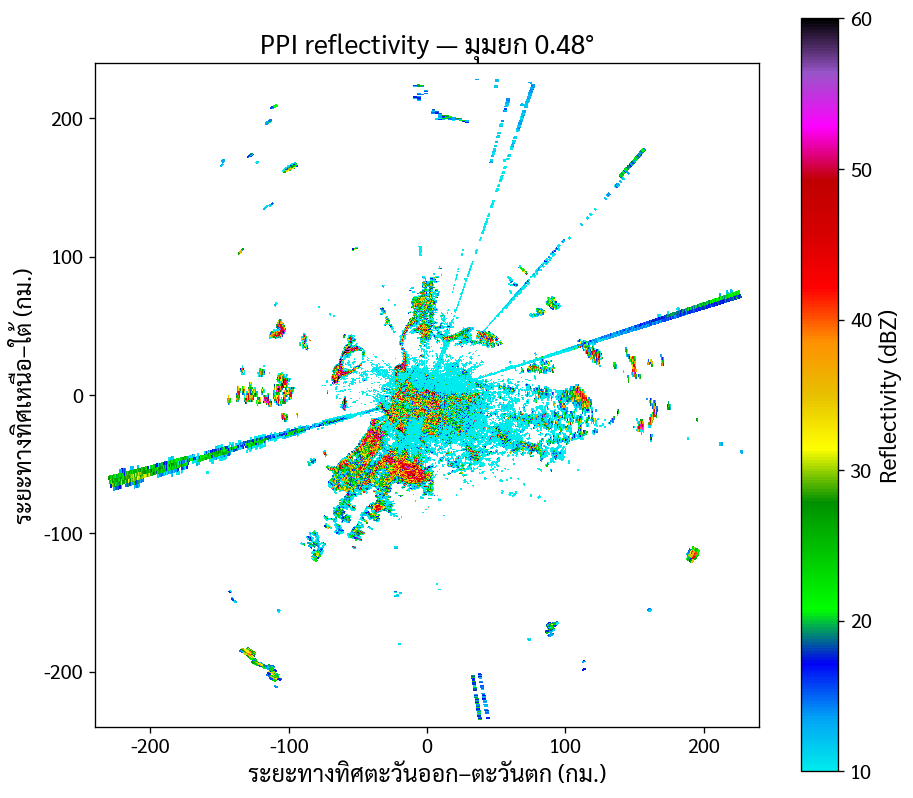

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))
display = pyart.graph.RadarDisplay(radar)
display.plot('reflectivity', sweep=0, ax=ax, vmin=10, vmax=60,
             cmap='NWSRef', colorbar_label='Reflectivity (dBZ)',
             title=f"PPI reflectivity — มุมยก {float(radar.fixed_angle['data'][0]):.2f}°")
ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
ax.set_xlabel('ระยะทางทิศตะวันออก–ตะวันตก (กม.)')
ax.set_ylabel('ระยะทางทิศเหนือ–ใต้ (กม.)')
plt.tight_layout(); plt.show()

## 3️⃣ เปรียบเทียบ PPI หลายมุมยก

เลือกมุมยกกระจายจากต่ำสุดถึงสูงสุด แล้วพลอตเทียบกัน เพื่อดูว่าโครงสร้างพายุเปลี่ยนไปอย่างไรเมื่อลำบีมยกสูงขึ้น


มุมยกที่เลือกเปรียบเทียบ (sweep): [0, 1, 2, 3] → [0.48, 1.48, 2.39, 3.39] °


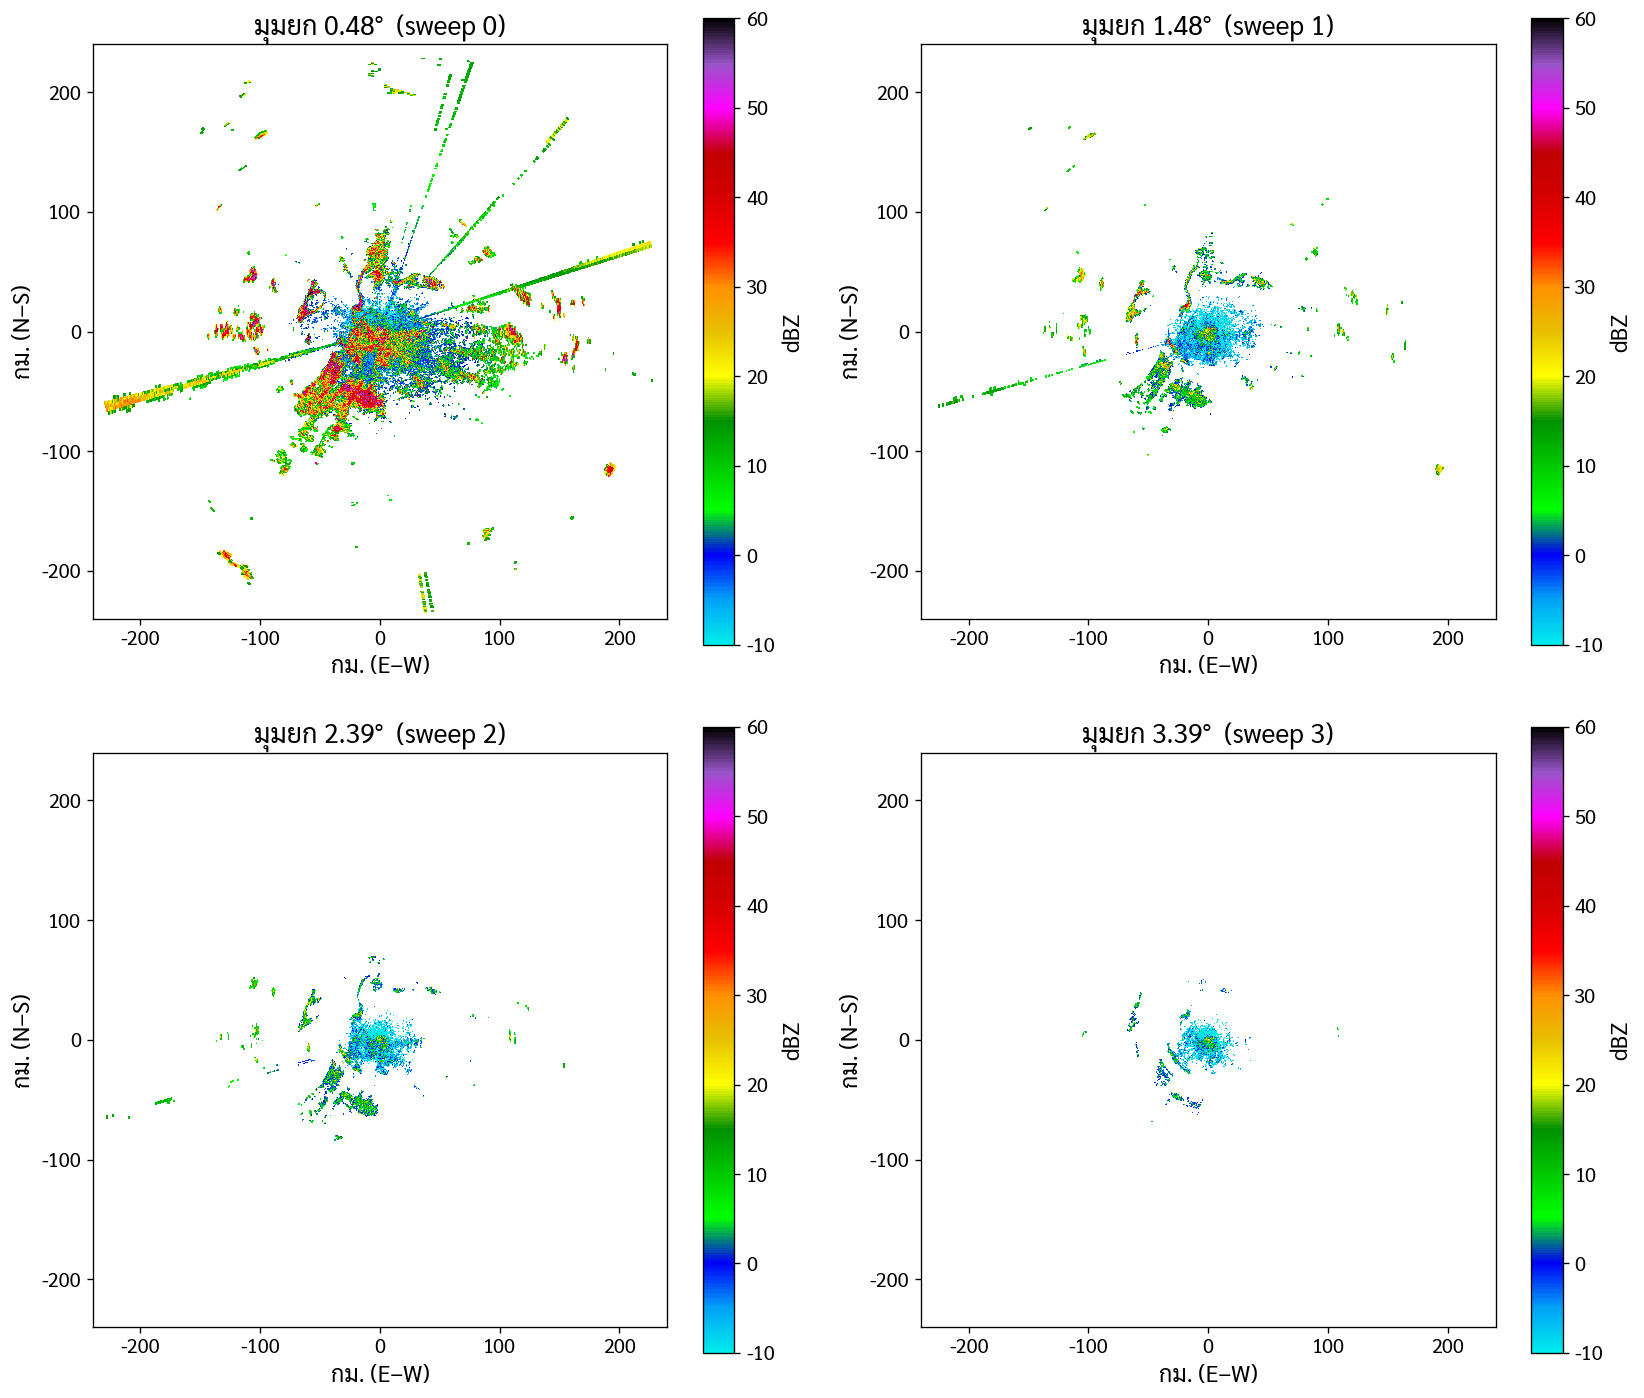

In [22]:
ns = radar.nsweeps
n_panel = min(4, ns)
sweep_idx = sorted(set(np.linspace(0, ns-1, n_panel).astype(int).tolist()))
print("มุมยกที่เลือกเปรียบเทียบ (sweep):", sweep_idx,
      "→", [round(float(radar.fixed_angle['data'][s]),2) for s in sweep_idx], "°")

ncols = 2
nrows = int(np.ceil(len(sweep_idx) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
axes = np.atleast_1d(axes).flatten()
disp = pyart.graph.RadarDisplay(radar)
for k, s in enumerate(sweep_idx):
    ax = axes[k]
    disp.plot('reflectivity', sweep=s, ax=ax, vmin=-10, vmax=60, cmap='NWSRef',
              colorbar_label='dBZ',
              title=f"มุมยก {float(radar.fixed_angle['data'][s]):.2f}°  (sweep {s})")
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
    ax.set_xlabel('กม. (E–W)'); ax.set_ylabel('กม. (N–S)')
for k in range(len(sweep_idx), len(axes)):
    axes[k].axis('off')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'ppi_compare_elevations.png'), bbox_inches='tight')
plt.show()

**สังเกต:** ที่มุมยกต่ำ ลำบีมอยู่ใกล้พื้น เห็นฝนครอบคลุมบริเวณกว้าง เมื่อมุมยกสูงขึ้น ลำบีมตัดผ่านส่วนบนของพายุ พื้นที่ครอบคลุมแคบลง (โดนเฉพาะแกนพายุที่ยกตัวสูง) — นี่คือพื้นฐานของการอ่านโครงสร้างแนวดิ่ง ซึ่งจะทำเป็นภาพตัด RHI/cross-section ในบทที่ 05


## 4️⃣ สำรวจฟิลด์ dual-polarization

พลอตทุกฟิลด์ที่มุมยกต่ำสุด (sweep 0) เพื่อเห็นข้อมูลที่เรดาร์ dual-pol ให้มา


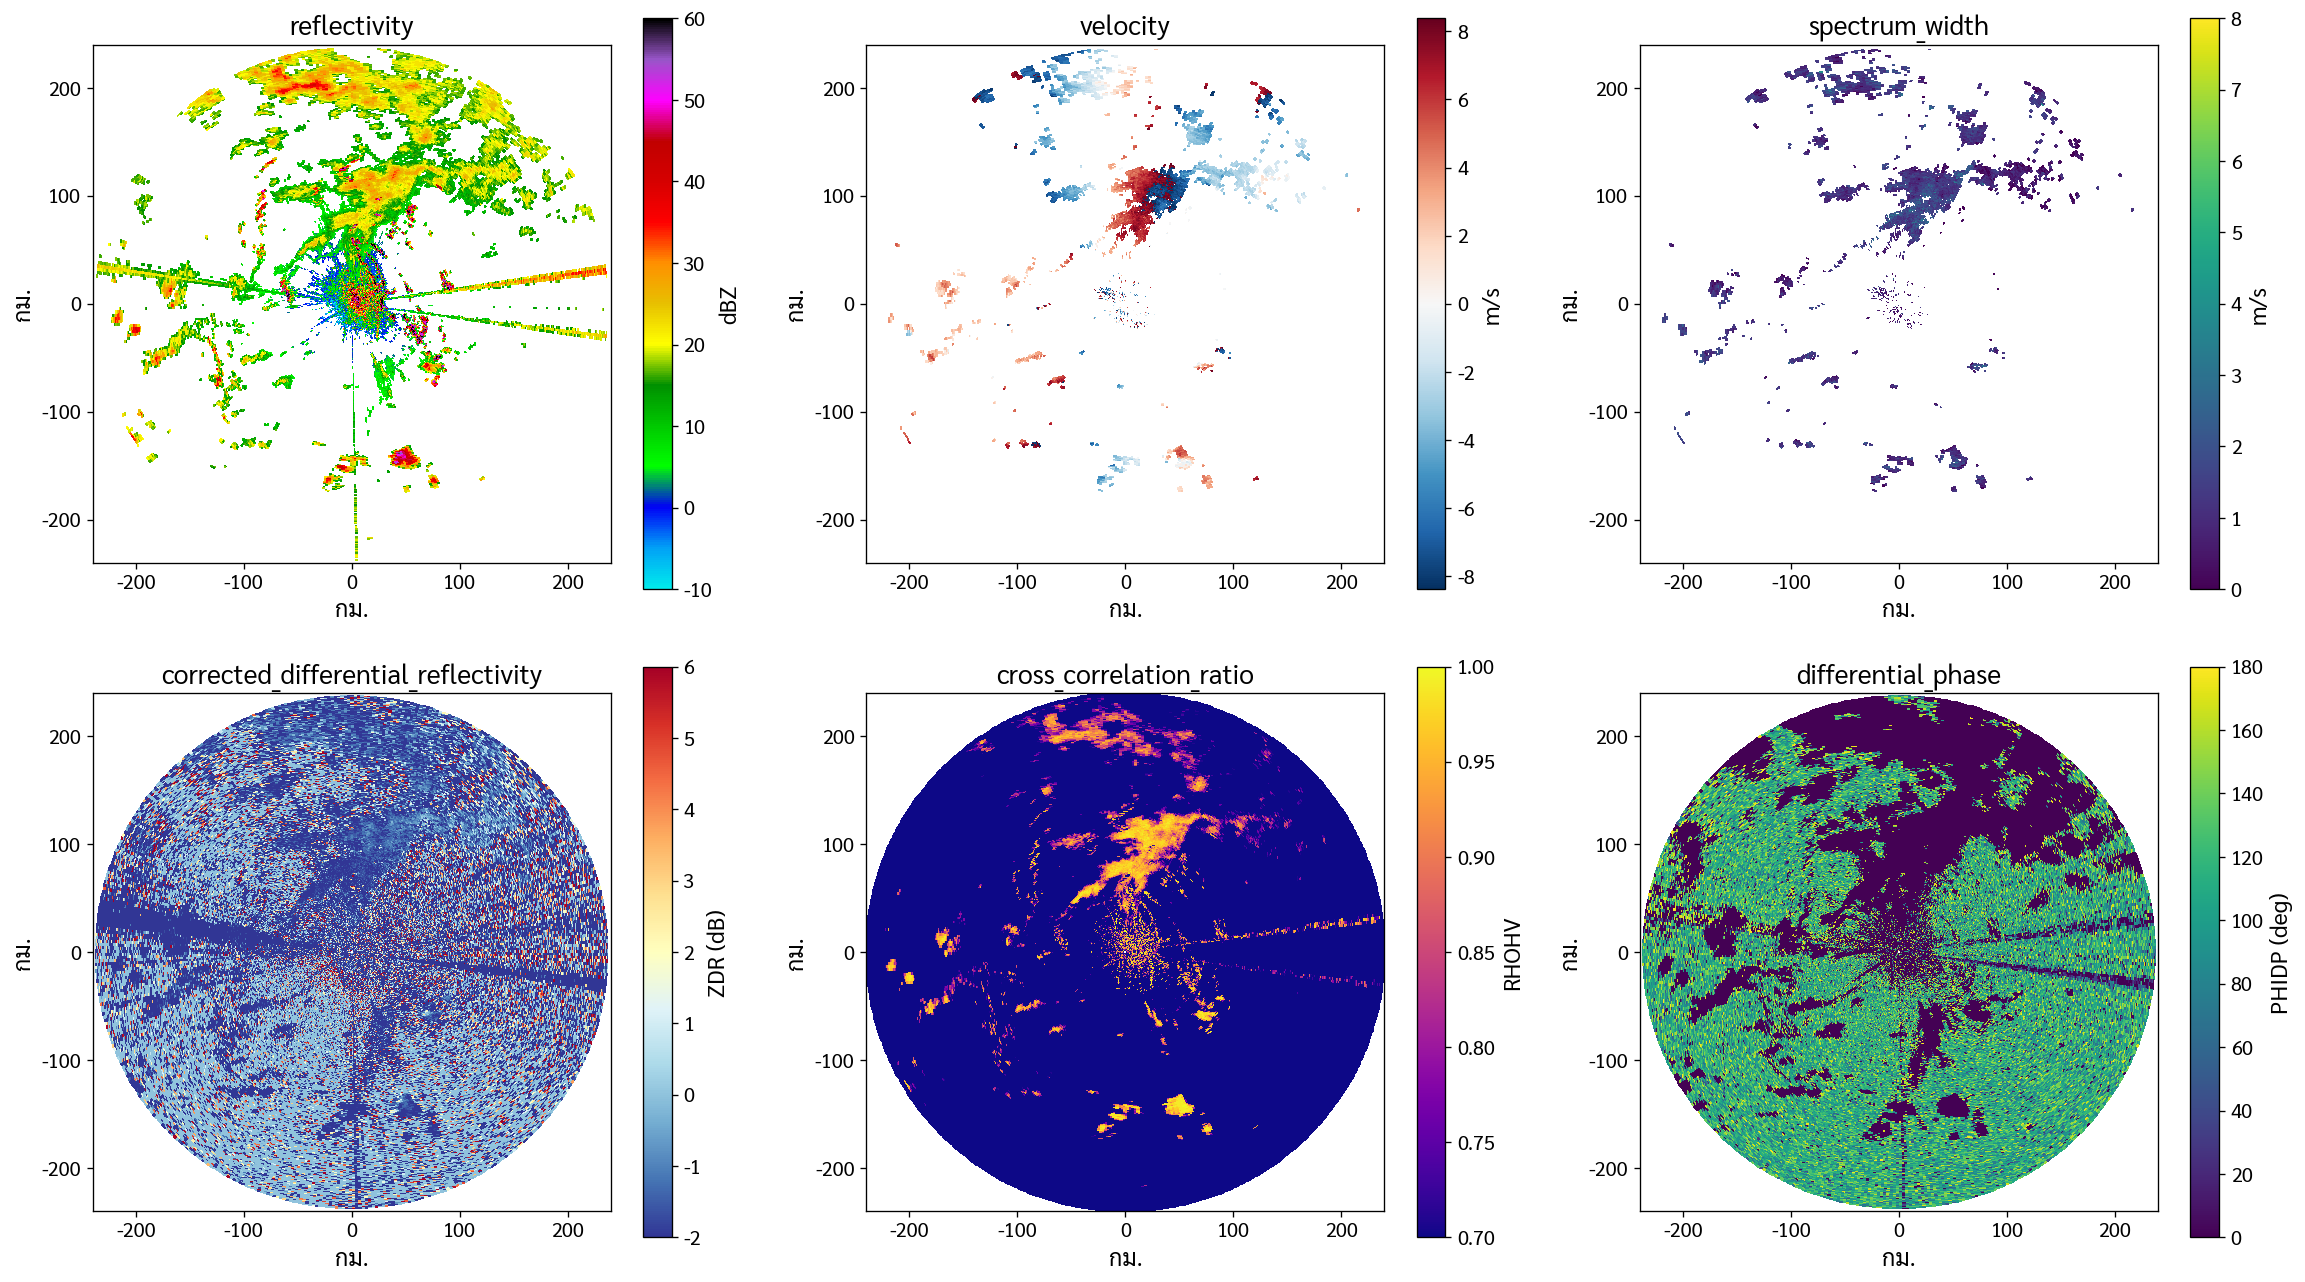

In [8]:
# กำหนดการแสดงผลของแต่ละฟิลด์ (cmap/ช่วงค่า/หน่วย) — ใช้ colormap มาตรฐานที่ปลอดภัย
field_style = {
    'reflectivity':                        ('NWSRef', -10, 60, 'dBZ'),
    'velocity':                            ('RdBu_r', -nyq, nyq, 'm/s'),
    'spectrum_width':                      ('viridis', 0, 8, 'm/s'),
    'corrected_differential_reflectivity': ('RdYlBu_r', -2, 6, 'ZDR (dB)'),
    'cross_correlation_ratio':             ('plasma', 0.7, 1.0, 'RHOHV'),
    'differential_phase':                  ('viridis', 0, 180, 'PHIDP (deg)'),
}
# เลือกเฉพาะฟิลด์ที่มีจริงในไฟล์
fields = [f for f in field_style if f in radar.fields]

ncols = 3
nrows = int(np.ceil(len(fields) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 5.5*nrows))
axes = np.atleast_1d(axes).flatten()
disp = pyart.graph.RadarDisplay(radar)
for k, f in enumerate(fields):
    cmap, vmin, vmax, label = field_style[f]
    ax = axes[k]
    disp.plot(f, sweep=0, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap,
              colorbar_label=label, title=f)
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')
for k in range(len(fields), len(axes)):
    axes[k].axis('off')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'dualpol_fields.png'), bbox_inches='tight')
plt.show()

**อ่านฟิลด์ dual-pol คร่าว ๆ:**
- **velocity** — สีคนละฝั่ง (เข้า/ออก) ช่วยดูการหมุนเวียนของลม; อาจเห็นการพับของค่า
- **RHOHV** ใกล้ 1 ในบริเวณฝนจริง ค่าต่ำมักเป็น clutter หรือขอบเมฆ → ใช้กรองคุณภาพในบทที่ 03
- **ZDR** เป็นบวกมากเมื่อเม็ดฝนใหญ่/แบน (ฝนหนัก) ใกล้ 0 เมื่อเป็นเม็ดกลมเล็ก


## 5️⃣ PPI แบบมีพิกัดภูมิศาสตร์ (เกริ่นก่อนบทที่ 06)

`RadarMapDisplay.plot_ppi_map` วางข้อมูลลงบนแผนที่จริง (lat/lon) พร้อมเส้นชายฝั่ง/เส้นกริด — บทที่ 06 จะทำให้สวยระดับตีพิมพ์พร้อมซ้อนขอบเขตจังหวัดและส่งออก GeoTIFF


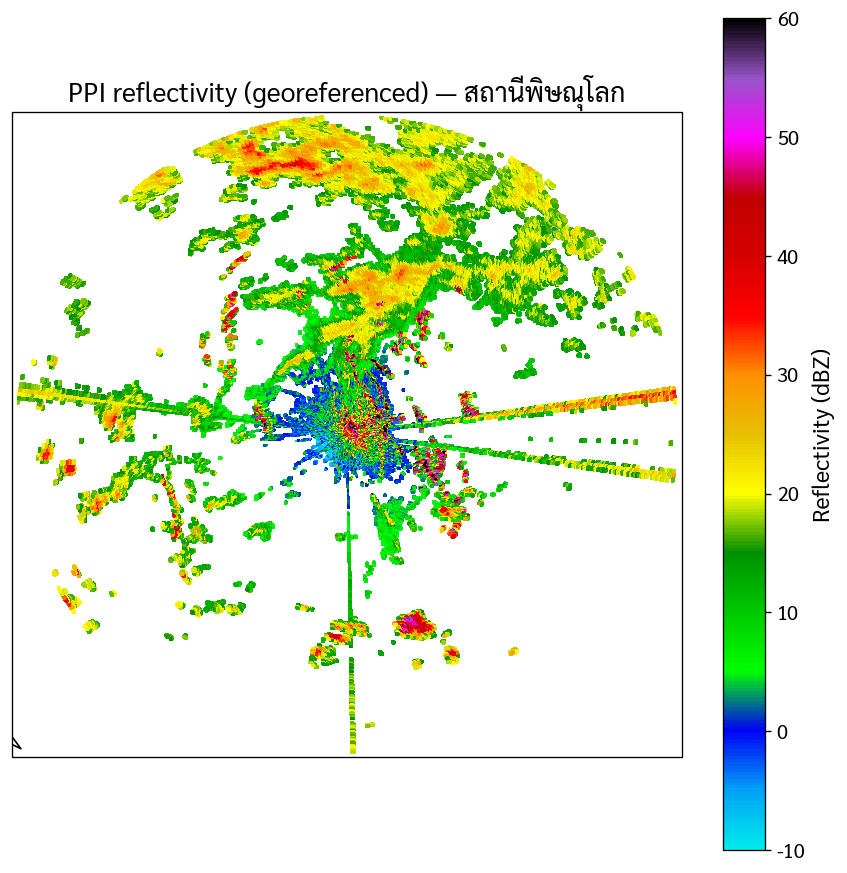

In [9]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(9, 9))
mapdisp = pyart.graph.RadarMapDisplay(radar)
mapdisp.plot_ppi_map(
    'reflectivity', sweep=0, vmin=-10, vmax=60, cmap='NWSRef',
    projection=ccrs.PlateCarree(), resolution='50m',
    colorbar_label='Reflectivity (dBZ)',
    title='PPI reflectivity (georeferenced) — สถานีพิษณุโลก',
)
fig.savefig(os.path.join(OUT, 'ppi_map_geographic.png'), bbox_inches='tight')
plt.show()

## 📝 แบบฝึกหัด

1. เปลี่ยน `sweep` ในหัวข้อ 2 ไปมุมยกอื่น ๆ — มุมยกใดเห็นแกนพายุ (ค่า dBZ สูง) ชัดที่สุด?
2. ลองปรับ `vmin`/`vmax` ของ reflectivity (เช่น 20–60) แล้วสังเกตว่ารายละเอียดของฝนหนักเด่นขึ้นอย่างไร
3. เปิดไฟล์เวลา 10:30 (`P.RADAR_1030`) แล้วพลอต PPI reflectivity sweep 0 เทียบกับ 10:00 — พายุเคลื่อนที่ไปทางใด?


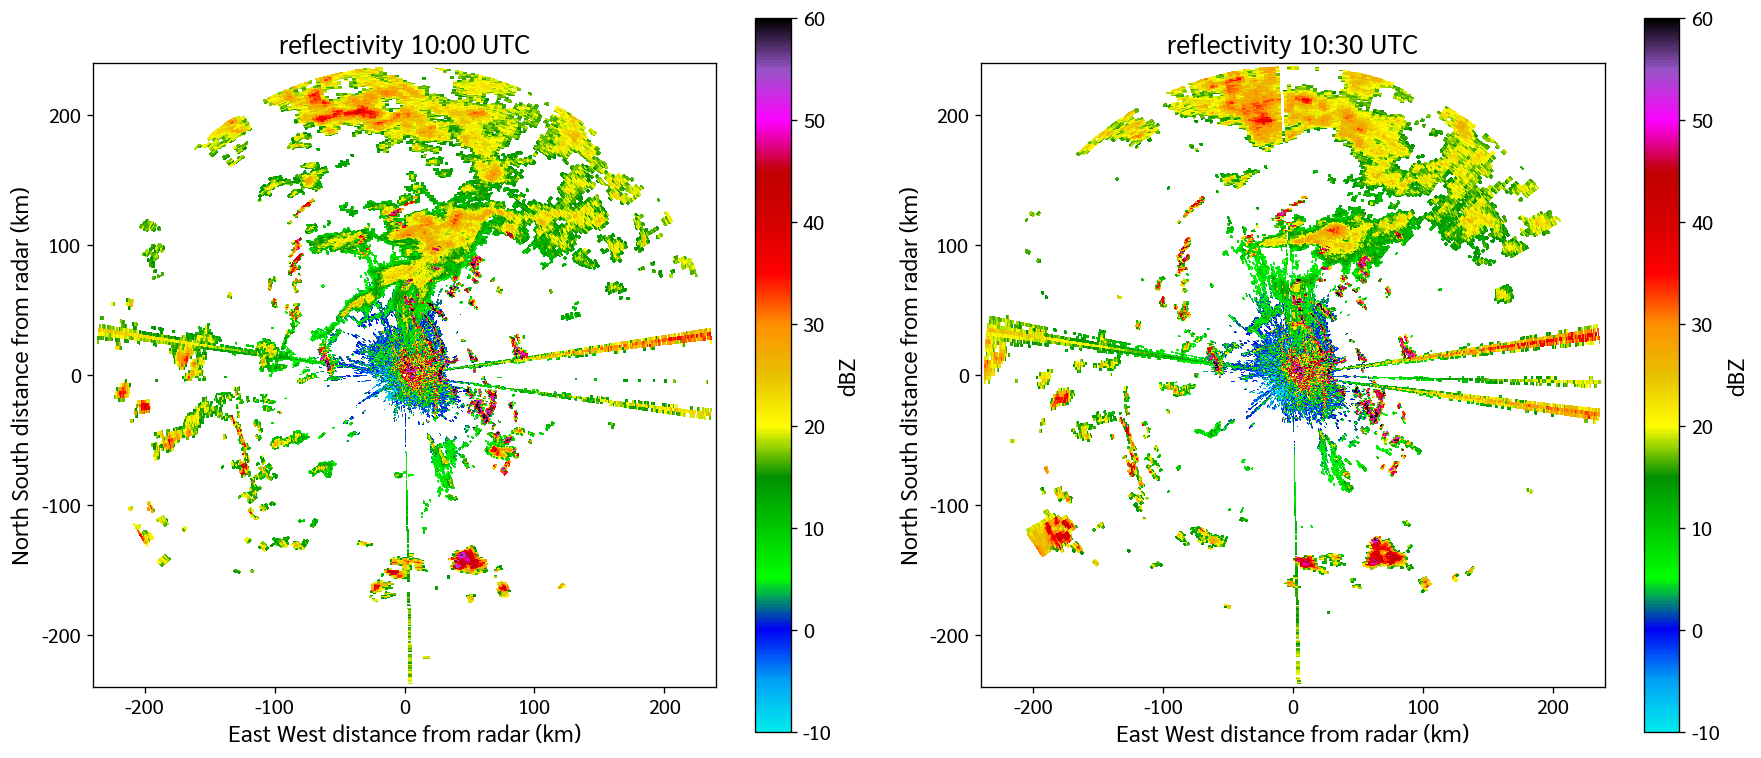

In [10]:
# แบบฝึกหัดข้อ 3 (โครงเริ่มต้น)
radar_1030 = pyart.io.read(P.RADAR_1030)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (rr, t) in zip(axes, [(radar, '10:00'), (radar_1030, '10:30')]):
    d = pyart.graph.RadarDisplay(rr)
    d.plot('reflectivity', sweep=0, ax=ax, vmin=-10, vmax=60, cmap='NWSRef',
           colorbar_label='dBZ', title=f'reflectivity {t} UTC')
    ax.set_xlim(-240,240); ax.set_ylim(-240,240); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
# TODO (นิสิต): สังเกตทิศทางการเคลื่อนตัวของกลุ่มฝน

---
## 🎯 สรุป

- อ่านไฟล์ด้วย `pyart.io.read` แล้วสำรวจ `radar.nsweeps`, `fixed_angle`, `fields`
- PPI = ภาพกวาดที่มุมยกคงที่ เปรียบเทียบหลายมุมยกช่วยเห็นโครงสร้างแนวดิ่งเบื้องต้น
- เรดาร์พิษณุโลกเป็น dual-pol มีฟิลด์ ZDR/PHIDP/RHOHV ที่จะใช้กรองคุณภาพและจำแนกฝนในบทถัด ๆ ไป

**บทถัดไป — บทที่ 03:** Gate filter & masking — การควบคุมคุณภาพข้อมูลก่อนนำไปคำนวณต่อ
